# Shor 9-Qubit QEC — Simulator

Implements and verifies the Shor 9-qubit quantum error correction code using Qiskit AerSimulator.

**Phases covered here:**
- Phase 1–3: Encoding, syndrome measurement, error correction — verified against known X/Y/Z errors
- Phase 4: Noise model experiments — depolarizing, amplitude damping, thermal-relaxation sweeps

In [1]:
import numpy as np
from qiskit.quantum_info import state_fidelity
from shor_code_utils import *
import Utilities as utils
import matplotlib.pyplot as plt

## Phase 1–3: Known Error Correction Verification

Generate a random state |ψ⟩ = α|0⟩ + β|1⟩, encode it, inject a known error, run syndrome
measurement + correction, and verify fidelity = 1.0 against the original state.

In [2]:
def test_known_error_correction(error_type, error_block, error_position):
    alpha, beta = create_arbirtary_state()

    initial_state, data_state = run(
        alpha, beta,
        error_block=error_block, error_position=error_position, error_type=error_type, shots=1024
    )

    print("Initial state:")
    utils.wavefunc(initial_state, precision=3)
    print("==================================")
    print("Corrected state (up to global phase):")
    utils.wavefunc(data_state, precision=3)
    print("==================================")
    fidelity = state_fidelity(initial_state, data_state)
    print(f"Fidelity: {fidelity:.4f}")



──────────────────── X ERROR ────────────────────



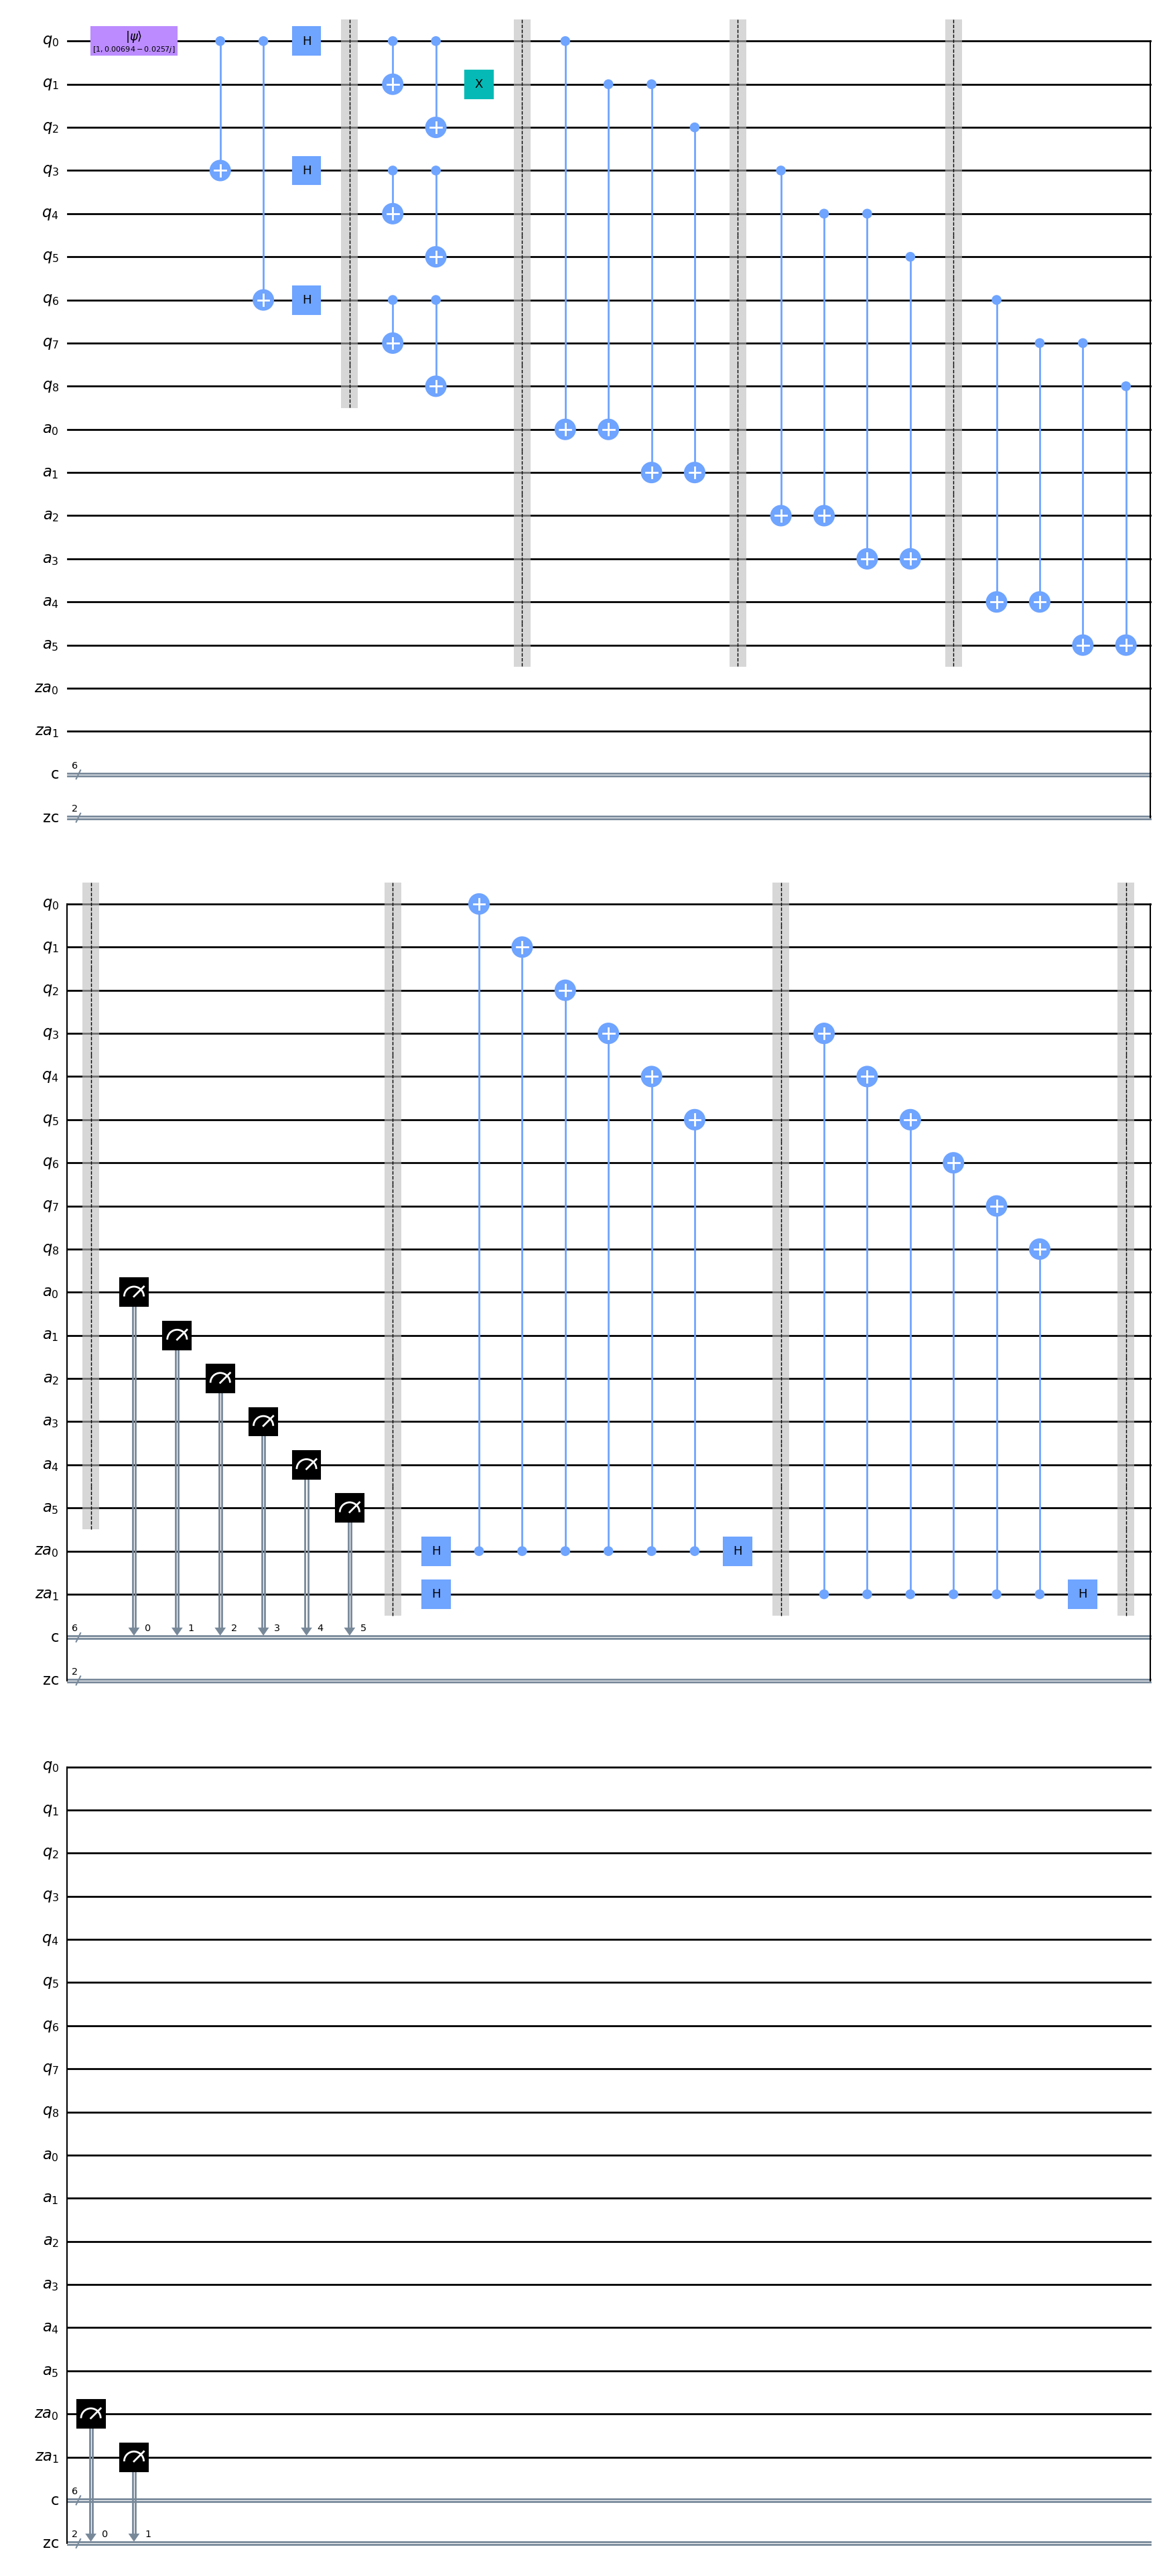

┌─────────┬────────┬──────────────┐
│ Block 0 │  11    │ middle qubit │
│ Block 1 │  00    │ no error     │
│ Block 2 │  00    │ no error     │
│ Z parity│  00    │ no error     │
└─────────┴────────┴──────────────┘
Initial state:
0.356-0.009j |000000000> + 0.351+0.009j |111000000> + 0.351+0.009j |000111000> + 0.356-0.009j |111111000> + 0.351+0.009j |000000111> + 0.356-0.009j |111000111> + 0.356-0.009j |000111111> + 0.351+0.009j |111111111>
Corrected state (up to global phase):
0.356 |000000000> + 0.351+0.018j |111000000> + 0.351+0.018j |000111000> + 0.356 |111111000> + 0.351+0.018j |000000111> + 0.356 |111000111> + 0.356 |000111111> + 0.351+0.018j |111111111>
Fidelity: 1.0000


──────────────────── Z ERROR ────────────────────



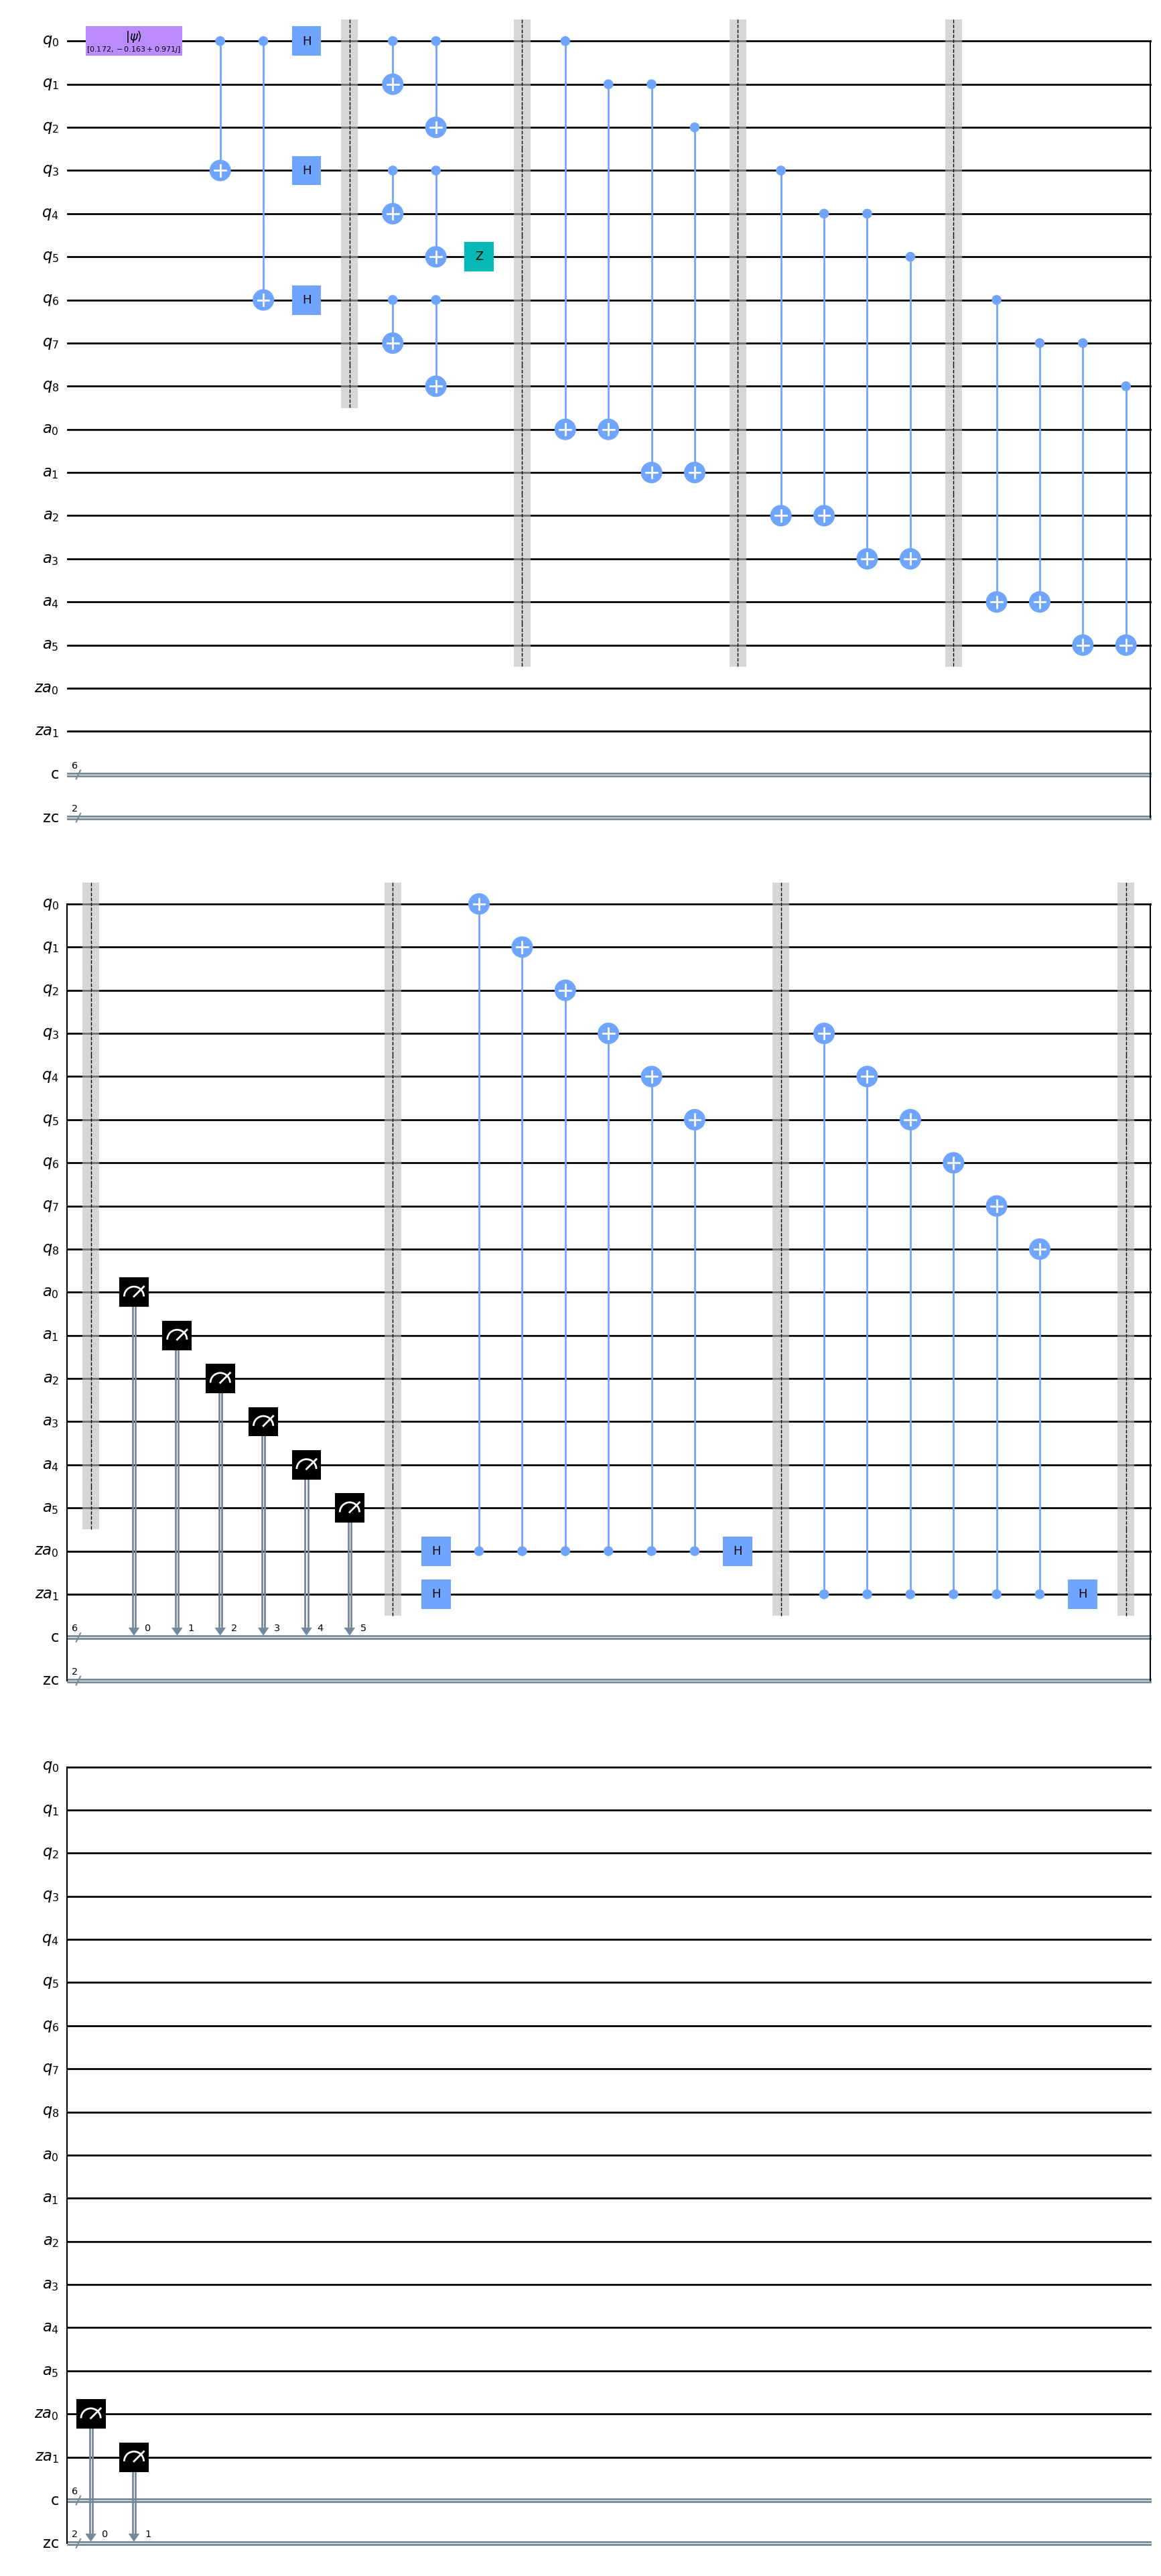

┌─────────┬────────┬──────────────┐
│ Block 0 │  00    │ no error     │
│ Block 1 │  00    │ no error     │
│ Block 2 │  00    │ no error     │
│ Z parity│  11    │ block 1      │
└─────────┴────────┴──────────────┘
Initial state:
0.003+0.343j |000000000> + 0.119-0.343j |111000000> + 0.119-0.343j |000111000> + 0.003+0.343j |111111000> + 0.119-0.343j |000000111> + 0.003+0.343j |111000111> + 0.003+0.343j |000111111> + 0.119-0.343j |111111111>
Corrected state (up to global phase):
0.343 |000000000> -0.342-0.122j |111000000> -0.342-0.122j |000111000> + 0.343 |111111000> -0.342-0.122j |000000111> + 0.343 |111000111> + 0.343 |000111111> -0.342-0.122j |111111111>
Fidelity: 1.0000


──────────────────── Y ERROR ────────────────────



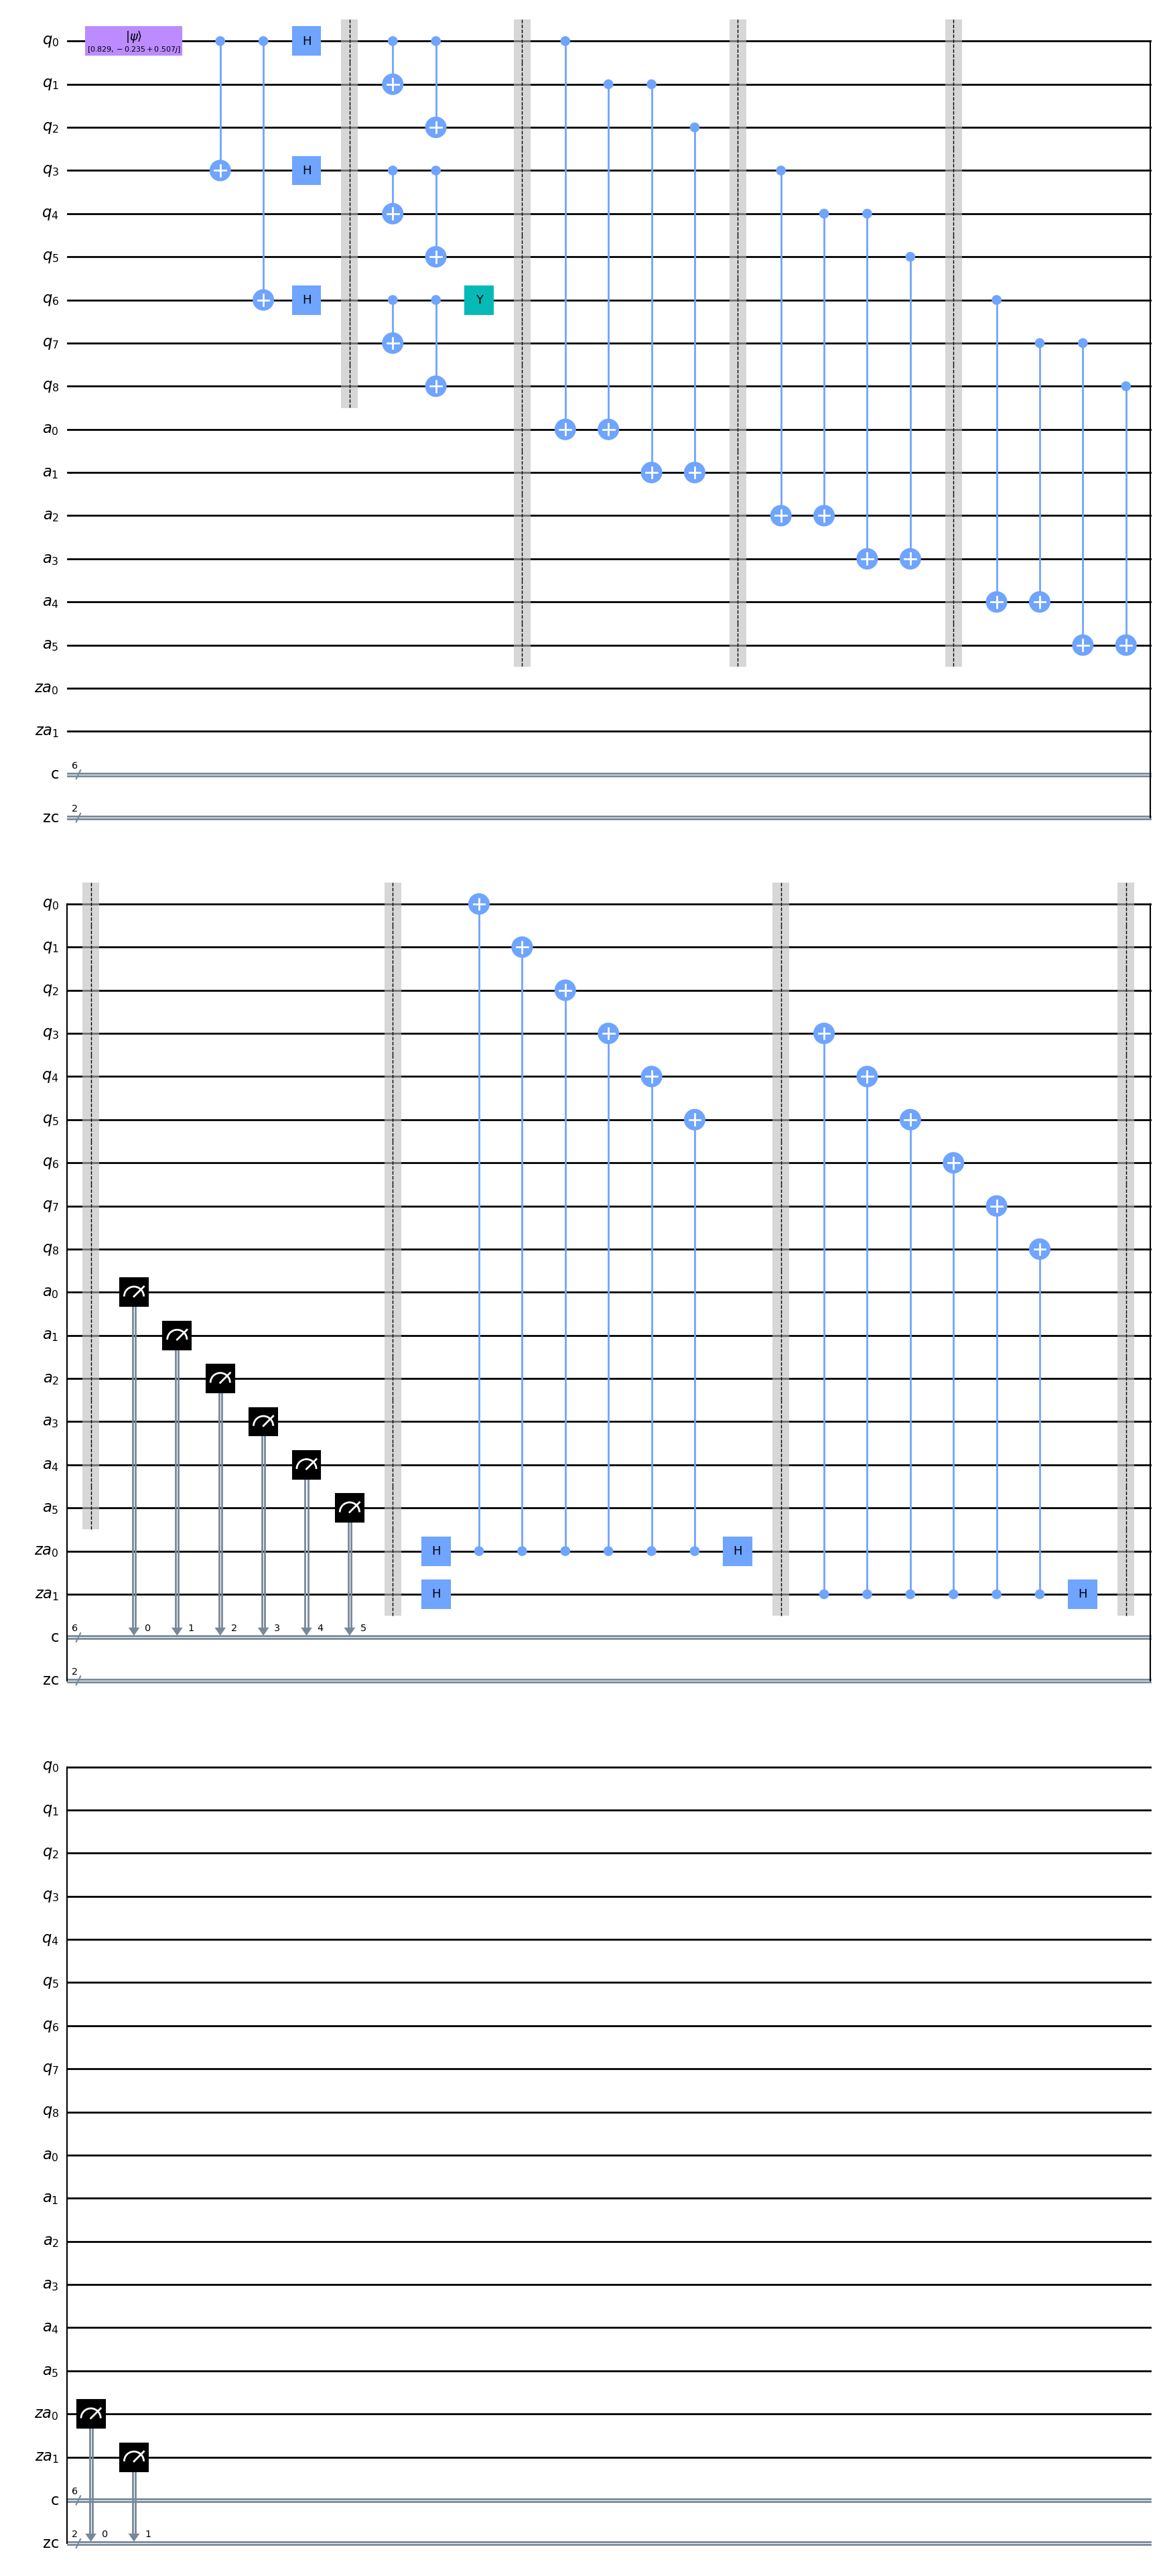

┌─────────┬────────┬──────────────┐
│ Block 0 │  00    │ no error     │
│ Block 1 │  00    │ no error     │
│ Block 2 │  10    │ left qubit   │
│ Z parity│  01    │ block 2      │
└─────────┴────────┴──────────────┘
Initial state:
0.21+0.179j |000000000> + 0.376-0.179j |111000000> + 0.376-0.179j |000111000> + 0.21+0.179j |111111000> + 0.376-0.179j |000000111> + 0.21+0.179j |111000111> + 0.21+0.179j |000111111> + 0.376-0.179j |111111111>
Corrected state (up to global phase):
0.276 |000000000> + 0.17-0.381j |111000000> + 0.17-0.381j |000111000> + 0.276 |111111000> + 0.17-0.381j |000000111> + 0.276 |111000111> + 0.276 |000111111> + 0.17-0.381j |111111111>
Fidelity: 1.0000


In [3]:
print(f"\n\n{'─'*20} X ERROR {'─'*20}\n")
test_known_error_correction(error_type='X', error_block=0, error_position=1)

print(f"\n\n{'─'*20} Z ERROR {'─'*20}\n")
test_known_error_correction(error_type='Z', error_block=1, error_position=2)

print(f"\n\n{'─'*20} Y ERROR {'─'*20}\n")
test_known_error_correction(error_type='Y', error_block=2, error_position=0)

## Phase 4: Noise Model Experiments

Phase 1–3 proved the code is **correct** against known errors. Phase 4 proves it is **useful** — errors are stochastic and applied after every gate across all 17 qubits (9 data + 8 ancilla).

### What we'll build

**`make_noise_model()`** — constructs a noise model where after each single-qubit gate (H, X, Y, Z) the qubit gets a random Pauli error with probability `p`, and after each two-qubit gate (CX) either qubit gets an error with probability `p`.

**`noise_sweep(p_values, make_noise_model, n_trials=50)`** — for each `p`:
- Build a noisy `AerSimulator` from the noise model
- Run `run()` `n_trials` times with random |ψ⟩, passing the noisy backend and `show_circuit=False`
- Compute mean logical error rate = `1 - mean(fidelity)` and std across trials

### Noise models to sweep
1. **Depolarizing** (primary) — random X, Y, or Z after every gate; tests the full Shor code
2. **Amplitude Damping** — |1> to |0> realistic
3. **Thermal Relaxation** — Ad and Dephasing together

### Sweep range
`p ∈ [0.001, 0.005, 0.01, 0.05, 0.1]`

Shor code corrects single-qubit errors only, so we expect:
- Below threshold: logical error rate << physical rate (code helps)
- Above threshold: multi-qubit errors dominate, code fails

### Output
Log-log plot: logical error rate vs physical error rate, QEC curves vs baseline, with mean ± std error bars. The crossing point is the **error threshold** — below it the Shor code is beneficial.

In [4]:
# implement the noise sweeps

p_values = [0.00001, 0.00005, 0.0001, 0.0005, 0.001, 0.005, 0.01]
tgate_values = [50, 100, 200, 500, 1000] # nanoseconds

n_qubits = 17  # 9 data + 8 ancilla for syndrome measurement
n_trials = 100  # number of random states to average over

depolarizing_error_results = noise_sweep(noise_type='depolarizing', p_values=p_values, n_qubits=n_qubits, n_trials=n_trials)
ad_results = noise_sweep(noise_type='amplitude_damping', p_values=p_values, n_qubits=n_qubits, n_trials=n_trials)
tr_results = noise_sweep(noise_type='thermal_relaxation', p_values=tgate_values, n_qubits=n_qubits, n_trials=n_trials)

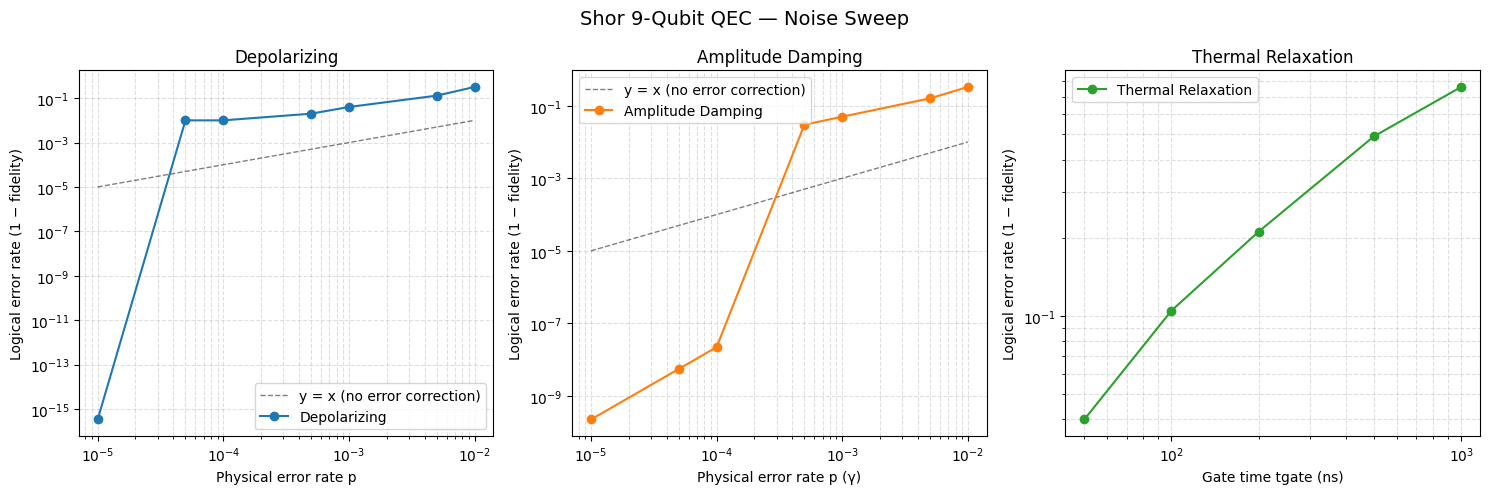

In [5]:
# start block for plotting the results

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

configs = [
    (depolarizing_error_results, "Depolarizing",       "tab:blue",   p_values,     "Physical error rate p"),
    (ad_results,                 "Amplitude Damping",  "tab:orange", p_values,     "Physical error rate p (γ)"),
    (tr_results,                 "Thermal Relaxation", "tab:green",  tgate_values, "Gate time tgate (ns)"),
]

for ax, (results, label, color, xs, xlabel) in zip(axes, configs):
    ps, _, errs_rate, _ = zip(*results)

    ax.errorbar(ps, errs_rate, color=color, marker='o',
                capsize=4, linewidth=1.5, label=label)

    if "tgate" not in xlabel:
        ax.plot(xs, xs, 'k--', linewidth=1, alpha=0.5, label='y = x (no error correction)')

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Logical error rate (1 − fidelity)")
    ax.set_title(label)
    ax.legend()
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.suptitle("Shor 9-Qubit QEC — Noise Sweep", fontsize=14)
plt.tight_layout()

